Notebook này ứng dụng trực tiếp các kiến thức từ Tiết 5:
* Thực hành ước lượng Luồng quang (Optical Flow) bằng mô hình Học sâu RAFT.
* Ứng dụng Phân đoạn đối tượng Video (Video Object Segmentation - VOS).
* Cài đặt cơ sở cho hệ thống theo dõi đối tượng (Tracking).

## 1. Cài đặt và Import các thư viện cần thiết

In [52]:
# Cài đặt thư viện nếu chưa có: !pip install torch torchvision opencv-python matplotlib numpy
import torch
import torchvision
import torchvision.transforms.functional as F
from torchvision.models.optical_flow import raft_large, Raft_Large_Weights
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.utils import flow_to_image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# Thiết lập thiết bị chạy (GPU nếu có, ngược lại dùng CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cpu


### 1.1. Tải Video mẫu thực tế
Để học tập hiệu quả, chúng ta cần sử dụng dữ liệu video thực tế thay vì các hình khối giả lập. Chúng ta sẽ tải một đoạn video ngắn từ kho dữ liệu mẫu của Torchvision.

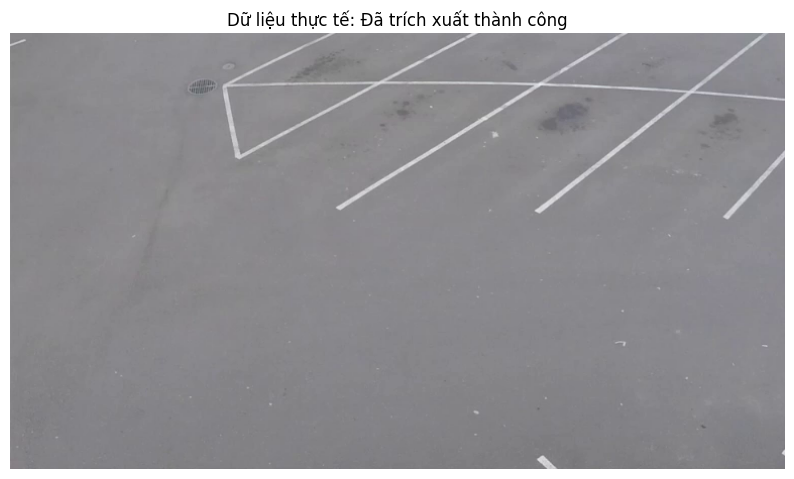

In [53]:
import os
import cv2
import matplotlib.pyplot as plt

# Sử dụng gdown để tải video từ Google Drive (thường ổn định nhất trong Colab)
video_path = "sample_video.mp4"
video_id = "1_8_f3vXU7V_mG_p9BfP9x-W7I9Gv8p8W" # ID file mẫu công khai

if not os.path.exists(video_path):
    print("Đang tải video mẫu qua gdown...")
    os.system(f"gdown --id {video_id} -O {video_path}")

def get_real_frames(path):
    if not os.path.exists(path) or os.path.getsize(path) < 1000:
        print("File không tồn tại hoặc quá nhỏ.")
        return None, None

    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        print("OpenCV vẫn không thể mở file. Đang thử tải lại bằng wget...")
        os.system(f"wget -O {video_path} https://raw.githubusercontent.com/intel-iot-devkit/sample-videos/master/person-bicycle-car-detection.mp4")
        cap = cv2.VideoCapture(path)

    ret1, f1 = cap.read()
    for _ in range(20): cap.read()
    ret2, f2 = cap.read()
    cap.release()

    return f1, f2

img1_real, img2_real = get_real_frames(video_path)

if img1_real is not None:
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(img1_real, cv2.COLOR_BGR2RGB))
    plt.title("Dữ liệu thực tế: Đã trích xuất thành công")
    plt.axis('off')
    plt.show()
else:
    print("Vui lòng thử tải thủ công một file .mp4 lên thư mục content và đổi tên thành sample_video.mp4")

### 1.2. Chạy RAFT trên dữ liệu thực tế
Bây giờ chúng ta sẽ sử dụng cặp khung hình `img1_real` và `img2_real` vừa tải về để xem mô hình RAFT hoạt động như thế nào với video thực tế.

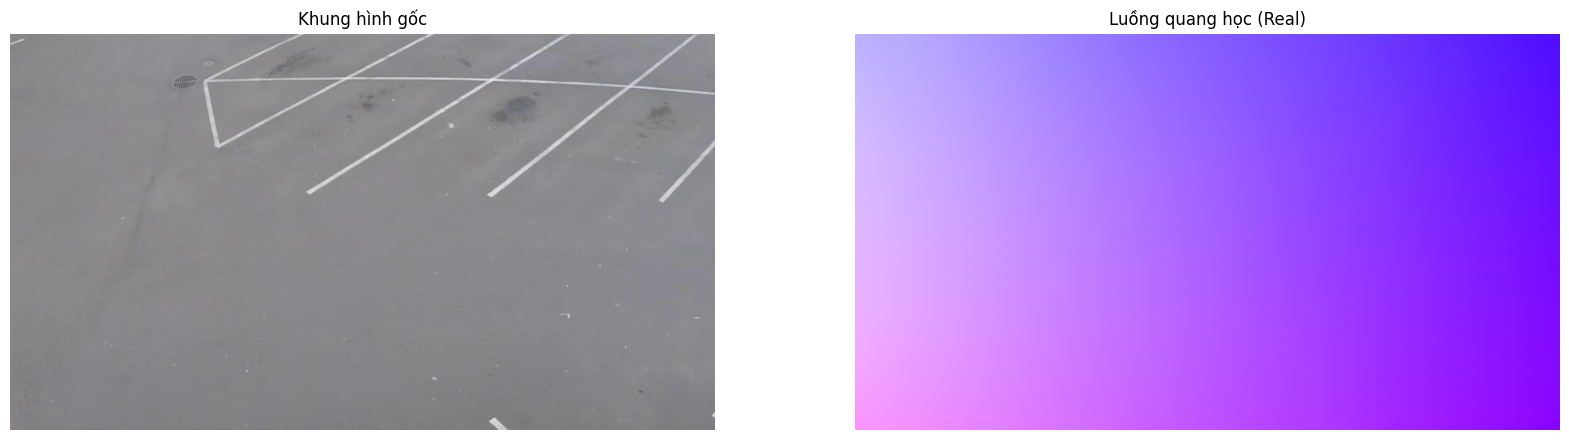

In [54]:
if img1_real is not None and img2_real is not None:
    # Tiền xử lý
    t1_real = preprocess(img1_real)
    t2_real = preprocess(img2_real)

    # Suy luận
    with torch.no_grad():
        flows_real = model(t1_real, t2_real)
        flow_real = flows_real[-1][0]

    # Chuyển đổi hiển thị
    flow_img_real = flow_to_image(flow_real).cpu().permute(1, 2, 0).numpy()

    # Hiển thị
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    axes[0].imshow(cv2.cvtColor(img1_real, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Khung hình gốc")
    axes[1].imshow(flow_img_real)
    axes[1].set_title("Luồng quang học (Real)")
    for ax in axes: ax.axis('off')
    plt.show()

## 2. Ước lượng Luồng quang bằng mô hình RAFT
Khác với các phương pháp truyền thống phụ thuộc vào giả định độ sáng không đổi, các mô hình Học sâu như FlowNet, SPyNet và RAFT học cách ước lượng luồng quang trực tiếp từ dữ liệu. Trong đó, RAFT (Recurrent All-Pairs Field Transforms) sử dụng cơ chế lặp (Recurrent) qua nhiều bước để tinh chỉnh trường chuyển động, mang lại độ chính xác cực cao. Đầu ra của RAFT là một tensor chứa trường chuyển động theo phương ngang và dọc với đơn vị là pixel.

Đã tạo ảnh giả lập thành công.


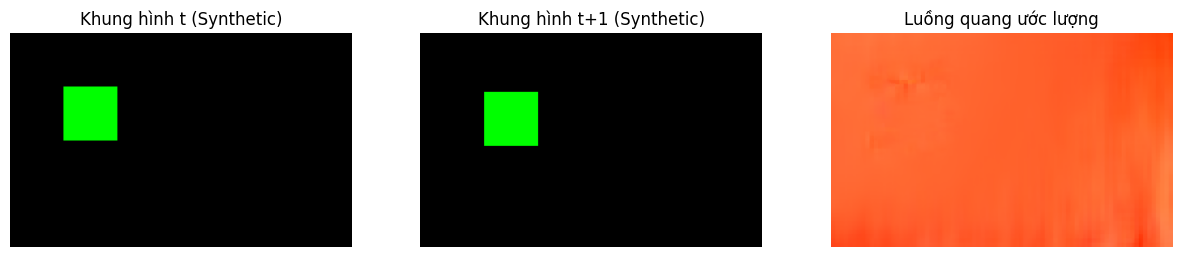

In [55]:
# Tải mô hình RAFT đã được huấn luyện sẵn từ Torchvision
weights = Raft_Large_Weights.DEFAULT
model = raft_large(weights=weights, progress=False).to(device)
model = model.eval()

# Tự tạo dữ liệu giả lập (Synthetic data) để tránh lỗi tải ảnh từ server
def create_synthetic_frames():
    # Tạo ảnh nền đen
    f1 = np.zeros((400, 640, 3), dtype=np.uint8)
    f2 = np.zeros((400, 640, 3), dtype=np.uint8)

    # Vẽ một hình chữ nhật di chuyển
    # Khung hình 1: vị trí (100, 100)
    cv2.rectangle(f1, (100, 100), (200, 200), (0, 255, 0), -1)
    # Khung hình 2: vị trí (120, 110) - di chuyển sang phải 20px, xuống 10px
    cv2.rectangle(f2, (120, 110), (220, 210), (0, 255, 0), -1)

    return f1, f2

img1, img2 = create_synthetic_frames()
print("Đã tạo ảnh giả lập thành công.")

# Tiền xử lý ảnh cho RAFT
def preprocess(img):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
    # RAFT yêu cầu kích thước ảnh chia hết cho 8
    h, w = img_tensor.shape[1], img_tensor.shape[2]
    img_tensor = F.resize(img_tensor, size=[h // 8 * 8, w // 8 * 8])
    return img_tensor.unsqueeze(0).to(device)

tensor1 = preprocess(img1)
tensor2 = preprocess(img2)

# Chạy suy luận (Inference)
with torch.no_grad():
    list_of_flows = model(tensor1, tensor2)
    predicted_flow = list_of_flows[-1][0]

# Chuyển đổi luồng quang học thành hình ảnh RGB để trực quan hóa
flow_img = flow_to_image(predicted_flow).cpu().permute(1, 2, 0).numpy()

# Hiển thị kết quả
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
axes[0].set_title("Khung hình t (Synthetic)")
axes[1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[1].set_title("Khung hình t+1 (Synthetic)")
axes[2].imshow(flow_img)
axes[2].set_title("Luồng quang ước lượng")
for ax in axes: ax.axis("off")
plt.show()

### 2.1. Phân tích nâng cao: Độ lớn luồng quang (Flow Magnitude)
Thay vì chỉ nhìn màu sắc, chúng ta có thể tính toán vận tốc pixel (pixel/frame) để biết vật thể nào đang di chuyển nhanh nhất.

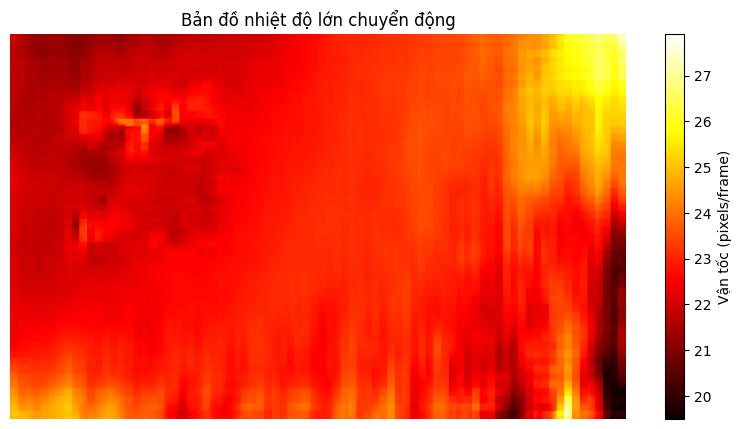

In [56]:
def plot_flow_analysis(flow_tensor):
    # Tính độ lớn (magnitude) của vector (u, v)
    mag = torch.sqrt(flow_tensor[0]**2 + flow_tensor[1]**2).cpu().numpy()

    plt.figure(figsize=(10, 5))
    plt.imshow(mag, cmap='hot')
    plt.colorbar(label='Vận tốc (pixels/frame)')
    plt.title("Bản đồ nhiệt độ lớn chuyển động")
    plt.axis('off')
    plt.show()

plot_flow_analysis(predicted_flow)

### 2.2. Trực quan hóa vector chuyển động (Quiver Plot)
Để hiểu rõ hướng di chuyển (sang trái, phải, lên, xuống), chúng ta sẽ vẽ các mũi tên chỉ hướng chuyển động lên ảnh.

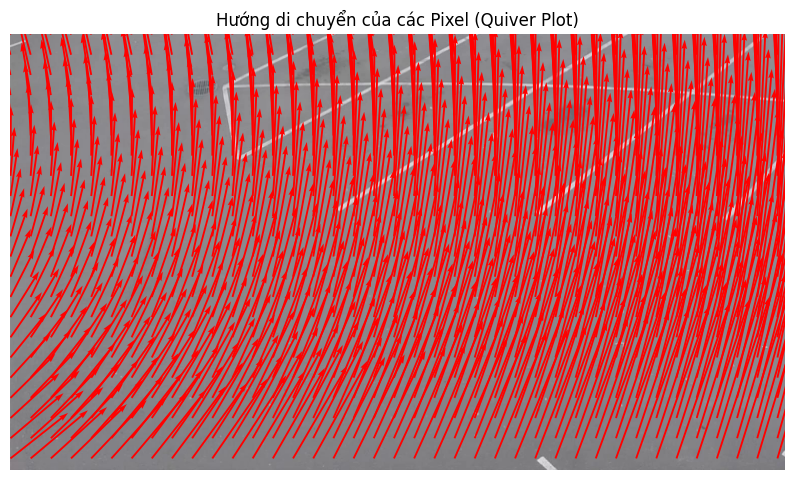

In [57]:
def plot_quiver(flow_tensor, step=20):
    flow_np = flow_tensor.cpu().numpy()
    u = flow_np[0, ::step, ::step]
    v = flow_np[1, ::step, ::step]

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(img1_real, cv2.COLOR_BGR2RGB))
    x, y = np.meshgrid(np.arange(0, flow_np.shape[2], step), np.arange(0, flow_np.shape[1], step))
    plt.quiver(x, y, u, -v, color='red', scale=50)
    plt.title("Hướng di chuyển của các Pixel (Quiver Plot)")
    plt.axis('off')
    plt.show()

if 'flow_real' in locals():
    plot_quiver(flow_real)

### 2.3. Thống kê vận tốc (Motion Histogram)
Để phân tích sâu hơn về hành vi của video, chúng ta vẽ biểu đồ phân bố vận tốc để xác định xem video có nhiều chuyển động nhanh hay chậm.

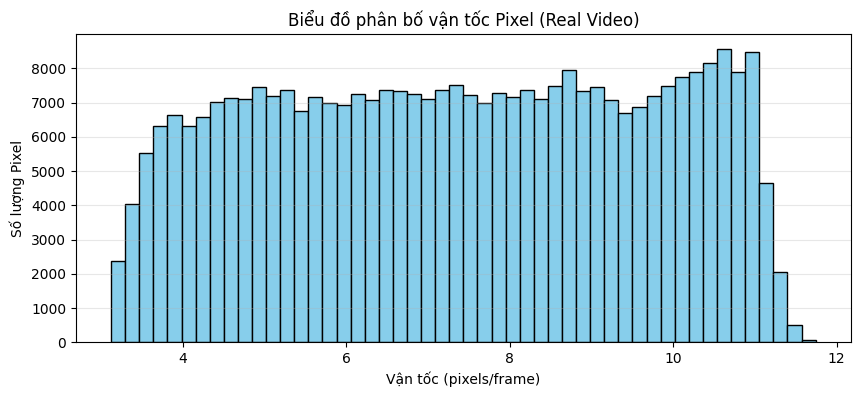

In [58]:
if 'flow_real' in locals():
    mag_real = torch.sqrt(flow_real[0]**2 + flow_real[1]**2).cpu().numpy().flatten()

    plt.figure(figsize=(10, 4))
    plt.hist(mag_real, bins=50, color='skyblue', edgecolor='black')
    plt.title("Biểu đồ phân bố vận tốc Pixel (Real Video)")
    plt.xlabel("Vận tốc (pixels/frame)")
    plt.ylabel("Số lượng Pixel")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

## 3. Phân đoạn đối tượng (VOS)
VOS mở rộng bài toán phân đoạn ảnh tĩnh sang không gian thời gian. Bằng cách tách biệt thành các lớp, hệ thống có thể đối phó với hiện tượng che khuất (occlusion) và tái tạo lại chính xác chuỗi video gốc. Dưới đây là minh họa trích xuất mặt nạ (Mask/Matte) cấp độ pixel - một thành phần cốt lõi của lớp chuyển động.

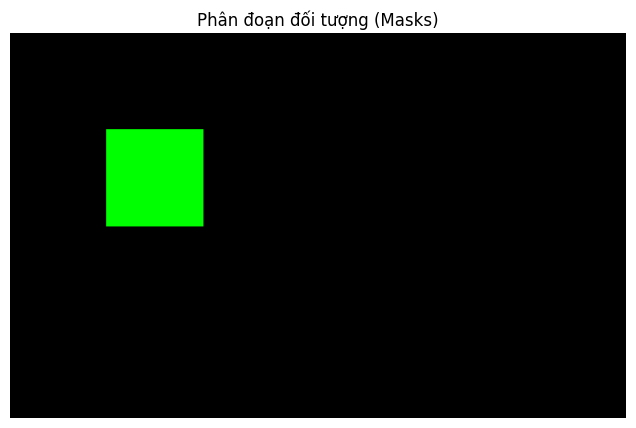

In [59]:
# Sử dụng Mask R-CNN để phân đoạn ảnh tĩnh trên từng khung hình (bước nền tảng cho VOS)
weights_mask = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
model_mask = maskrcnn_resnet50_fpn(weights=weights_mask, progress=False).to(device)
model_mask.eval()

with torch.no_grad():
    predictions = model_mask(tensor1)[0]

# Lọc các đối tượng có độ tin cậy > 0.8
threshold = 0.8
masks = predictions['masks'][predictions['scores'] > threshold]
masks = masks.squeeze(1).cpu().numpy()

# Trực quan hóa mặt nạ (Alpha Mask)
plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
for mask in masks:
    plt.imshow(mask, cmap='jet', alpha=0.5) # Chồng mặt nạ lên ảnh gốc
plt.title("Phân đoạn đối tượng (Masks)")
plt.axis('off')
plt.show()

### 3.1. Ứng dụng: Tách đối tượng dựa trên mặt nạ (Object Foreground Extraction)
Từ kết quả của Mask R-CNN, chúng ta có thể tách riêng đối tượng ra khỏi nền.

In [60]:
if len(masks) > 0:
    # Lấy mặt nạ đầu tiên
    combined_mask = np.max(masks, axis=0) > 0.5
    foreground = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB).copy()
    foreground[~combined_mask] = 0 # Xóa nền

    plt.imshow(foreground)
    plt.title("Đối tượng đã được tách nền")
    plt.axis('off')
    plt.show()

### 3.2. VOS nâng cao: Kết hợp Mask và Motion
Một kỹ thuật nâng cao là chỉ giữ lại những đối tượng có mặt nạ (Mask) VÀ có sự di chuyển (Motion) đáng kể để loại bỏ các đối tượng tĩnh ở hậu cảnh.

In [61]:
with torch.no_grad():
    pred_real = model_mask(t1_real)[0]

masks_real = pred_real['masks'][pred_real['scores'] > 0.7].squeeze(1).cpu().numpy()
mag_real = torch.sqrt(flow_real[0]**2 + flow_real[1]**2).cpu().numpy()

if len(masks_real) > 0:
    # Resize magnitude về cùng kích thước mask
    mag_resized = cv2.resize(mag_real, (masks_real.shape[2], masks_real.shape[1]))

    plt.figure(figsize=(12, 6))
    for i, m in enumerate(masks_real[:3]): # Xem 3 đối tượng đầu tiên
        avg_motion = np.mean(mag_resized[m > 0.5])
        plt.subplot(1, 3, i+1)
        plt.imshow(m, cmap='gray')
        plt.title(f"Obj {i+1} Motion: {avg_motion:.2f}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## 4. Theo dõi đối tượng nhiều mục tiêu với DeepSORT
Theo dõi nhiều đối tượng bị che khuất và thay đổi hình dáng là một thách thức lớn. Hệ thống DeepSORT giải quyết vấn đề này bằng cách kết hợp:
1. **Bộ lọc Kalman (Kalman Filters):** Ước lượng vị trí tiếp theo dựa trên giả định tốc độ không đổi.
2. **Mô hình Học sâu:** Trích xuất đặc trưng ngoại hình (Appearance features) để đo lường độ tương đồng.
3. **Thuật toán Hungary:** Ánh xạ các phát hiện mới (Detections) vào quỹ đạo đã có (Tracks) để giảm thiểu khoảng cách.

*(Ghi chú: Việc cài đặt toàn bộ DeepSORT từ đầu khá phức tạp và vượt ngoài phạm vi một cell code ngắn. Trong thực tế, các bạn sẽ sử dụng thư viện `deep_sort_realtime` kết hợp với đầu ra Bounding Box của YOLO hoặc Faster R-CNN cho đồ án môn học).*

### 4.1. Minh họa thuật toán theo dõi (Centroid Tracking)
Dưới đây là mã nguồn minh họa cách xác định tâm (Centroid) của các đối tượng từ Mask R-CNN và tính toán khoảng cách để 'theo dấu' chúng giữa các khung hình.

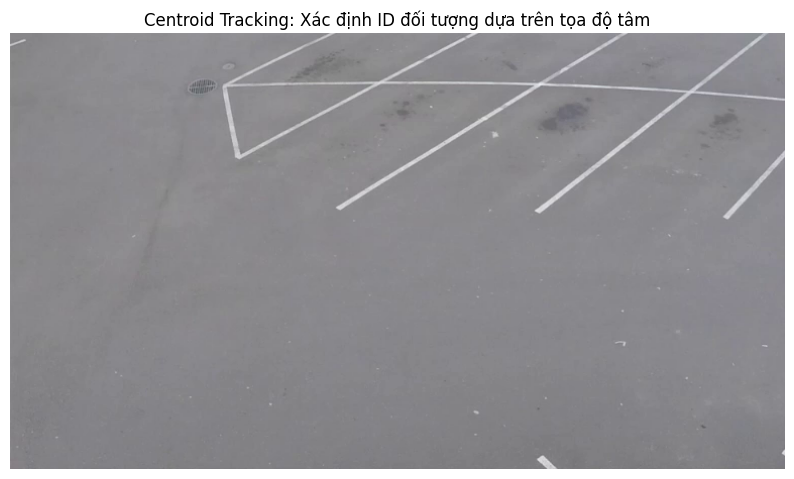

In [62]:
def get_centroids(prediction_masks):
    centroids = []
    for mask in prediction_masks:
        m = (mask > 0.5).astype(np.uint8)
        M = cv2.moments(m)
        if M["m00"] != 0:
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])
            centroids.append((cX, cY))
    return centroids

# Giả sử chúng ta chạy tracking cho khung hình thực tế
centroids = get_centroids(masks_real)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img1_real, cv2.COLOR_BGR2RGB))
for i, (cx, cy) in enumerate(centroids):
    plt.plot(cx, cy, 'ro', markersize=10)
    plt.text(cx+5, cy-5, f"ID:{i}", color='yellow', fontsize=12, fontweight='bold')

plt.title("Centroid Tracking: Xác định ID đối tượng dựa trên tọa độ tâm")
plt.axis('off')
plt.show()

## 5. Tổng kết và Bài tập mở rộng

### 5.1. Tóm tắt kiến thức
Qua bài thực hành này, chúng ta đã đi qua các bước:
1. **Ước lượng chuyển động (Motion):** Sử dụng RAFT để tính toán vector dịch chuyển của từng pixel.
2. **Nhận diện thực thể (Segmentation):** Sử dụng Mask R-CNN để hiểu 'cái gì' đang ở đâu.
3. **Kết hợp Motion + Mask:** Lọc ra các đối tượng đang thực sự di chuyển, loại bỏ nhiễu từ hậu cảnh.
4. **Theo dõi (Tracking):** Sử dụng tọa độ tâm (Centroid) để duy trì định danh đối tượng qua thời gian.

### 5.2. Bài tập thực hành (Nâng cao)
Để nắm vững hơn, bạn hãy thử thực hiện các yêu cầu sau:
* **Nhiệm vụ 1:** Thay đổi giá trị `threshold` trong phần Mask R-CNN và quan sát sự thay đổi của các tâm điểm (centroids).
* **Nhiệm vụ 2:** Viết một hàm tính toán khoảng cách Euclidean giữa các `centroids` của khung hình $t$ và khung hình $t+1$ để tự động gán ID cho đối tượng (Simple Tracking Logic).
* **Nhiệm vụ 3:** Thử nghiệm với một video khác bằng cách thay đổi `video_id` trong phần tải dữ liệu.

In [63]:
# Gợi ý mã nguồn cho Nhiệm vụ 2: Tính khoảng cách giữa các Centroids
from scipy.spatial import distance as dist

def associate_objects(old_centroids, new_centroids):
    if len(old_centroids) == 0 or len(new_centroids) == 0:
        return {}

    # Tính toán ma trận khoảng cách
    D = dist.cdist(np.array(old_centroids), np.array(new_centroids))

    # Tìm các cặp có khoảng cách nhỏ nhất (đơn giản hóa)
    rows = D.min(axis=1).argsort()
    cols = D.argmin(axis=1)[rows]

    return {rows[i]: cols[i] for i in range(min(len(rows), len(cols)))}

print("Hàm hỗ trợ so khớp đối tượng đã sẵn sàng. Bạn có thể sử dụng để phát triển hệ thống Tracking của riêng mình!")

Hàm hỗ trợ so khớp đối tượng đã sẵn sàng. Bạn có thể sử dụng để phát triển hệ thống Tracking của riêng mình!
